<a href="https://colab.research.google.com/github/thanteeeee/Overfitters/blob/main/EDA_Sleep_Analysis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Cleaning

In [23]:
import pandas as pd
import numpy as np
import re

# โหลดไฟล์
df = pd.read_excel("แบบสำรวจการใช้มือถือส่งผลกับการนอนหรือไม่ (การตอบกลับ).xlsx")

# ==========================
# เปลี่ยนชื่อคอลัมน์
# ==========================
df.columns = [
    "timestamp",
    "age",
    "sleep_hours",
    "morning_freshness",
    "screen_time",
    "use_phone_before_sleep",
    "stress_level",
    "phone_anxiety",
    "health_app_use",
    "sleep_quality",
    "phone_affects_sleep"
]

# ==========================
# ฟังก์ชันแปลงเป็นเลขเดียว
# ==========================
def clean_numeric(value):
    if pd.isna(value):
        return np.nan

    value = str(value).strip()

    # ถ้ามีตัวอักษรแปลกมากเกินไป
    if "ล้านปีแสง" in value:
        return np.nan

    # กรณีช่วง เช่น 6-8
    range_match = re.search(r'(\d+\.?\d*)\s*[-–]\s*(\d+\.?\d*)', value)
    if range_match:
        low = float(range_match.group(1))
        high = float(range_match.group(2))
        return (low + high) / 2

    # กรณีเลขตัวเดียว
    single_match = re.search(r'(\d+\.?\d*)', value)
    if single_match:
        return float(single_match.group(1))

    return np.nan

# ==========================
# คอลัมน์ตัวเลข
# ==========================
numeric_cols = ["age", "sleep_hours", "screen_time", "stress_level"]

for col in numeric_cols:
    df[col] = df[col].apply(clean_numeric)

# ==========================
# กรองค่าผิดปกติ
# ==========================
df["age"] = df["age"].where(df["age"].between(10, 80))
df["sleep_hours"] = df["sleep_hours"].where(df["sleep_hours"].between(1, 24))
df["screen_time"] = df["screen_time"].where(df["screen_time"].between(0, 24))
df["stress_level"] = df["stress_level"].where(df["stress_level"].between(1, 10))

# ==========================
# ลบแถวที่สำคัญเป็น NaN
# ==========================
df = df.dropna(subset=["age", "sleep_hours", "screen_time"])

# ==========================
# บันทึกไฟล์ใหม่
# ==========================
df.to_excel("cleaned_thai_data.xlsx", index=False)

print("Cleaned successfully")

Cleaned successfully


In [21]:
import pandas as pd

# โหลดไฟล์
df_en = pd.read_csv("Impact of Digital Device Usage on Sleep Quality and Mental Healthcsv.csv")

# ดูข้อมูล
print(df_en.head())
print(df_en.info())

# ลบข้อมูลซ้ำ
df_en = df_en.drop_duplicates()

# ปรับชื่อ column
df_en.columns = df_en.columns.str.strip().str.lower().str.replace(" ", "_")

# ทำข้อความให้เหมือนกัน
for col in df_en.select_dtypes(include='object').columns:
    df_en[col] = df_en[col].str.strip().str.lower()

# ตรวจ missing
print(df_en.isnull().sum())

# กรองค่าผิดปกติ
if "age" in df_en.columns:
    df_en = df_en[(df_en["age"] >= 10) & (df_en["age"] <= 100)]

# บันทึก
df_en.to_csv("cleaned_english_data.csv", index=False)

print("English data cleaned")

   Age  Sleep Hours Feel Rested  Daily Screen Time Use Before Sleep  \
0   47            4         Yes                 11              Yes   
1   48            4          No                  8               No   
2   40            7   Sometimes                 10               No   
3   26           10         Yes                  5              Yes   
4   47            5         Yes                  7              Yes   

   Stress Level Anxiety/Low Mood Wellness Apps Sleep Quality  \
0            10               No            No           Bad   
1             7              Yes           Yes           Bad   
2             4               No           Yes           Bad   
3             1              Yes            No          Good   
4             7              Yes            No          Good   

  Screen Time Affects Sleep?  
0                        Yes  
1                        Yes  
2                        Yes  
3                         No  
4                        Yes  
<c

# EDA

========== THAI SURVEY DATA ==========


,Column,Data Type,Missing Values,Unique Values
0,timestamp,datetime64[ns],0,83
1,age,int64,0,15
2,sleep_hours,float64,0,16
3,morning_freshness,object,0,2
4,screen_time,float64,0,22
5,use_phone_before_sleep,object,0,2
6,stress_level,int64,0,10
7,phone_anxiety,object,0,2
8,health_app_use,object,0,2
9,sleep_quality,object,0,2


,timestamp,age,sleep_hours,morning_freshness,screen_time,use_phone_before_sleep,stress_level,phone_anxiety,health_app_use,sleep_quality,phone_affects_sleep
0,2026-04-04 21:38:57.931000,20,3.000000,ไม่สดชื่น,14.000000,ใช่,5,ไม่หงุดหงิด/ไม่วิตกกังวล,ไม่ใช่,ไม่ดี,ไม่แน่ใจ
1,2026-04-04 21:39:12.904000,20,6.000000,ไม่สดชื่น,7.000000,ใช่,6,ไม่หงุดหงิด/ไม่วิตกกังวล,ไม่ใช่,ดี,ใช่
2,2026-04-04 21:39:17.371000,23,10.000000,สดชื่น,14.000000,ใช่,3,ไม่หงุดหงิด/ไม่วิตกกังวล,ไม่ใช่,ดี,ใช่
3,2026-04-04 21:41:24.121000,21,6.000000,ไม่สดชื่น,9.000000,ใช่,7,ไม่หงุดหงิด/ไม่วิตกกังวล,ไม่ใช่,ไม่ดี,ใช่
4,2026-04-04 21:41:36.062000,20,6.000000,ไม่สดชื่น,16.000000,ใช่,7,หงุดหงิด/วิตกกังวล,ใช่,ไม่ดี,ไม่ใช่


,age,sleep_hours,screen_time,stress_level
count,83.000000,83.000000,83.000000,83.000000
mean,21.048193,6.795181,9.087952,5.409639
std,6.461714,1.747884,4.132188,2.036473
min,16.000000,2.500000,1.500000,1.000000
25%,18.000000,6.000000,6.000000,4.000000
50%,20.000000,7.000000,9.000000,5.000000
75%,21.000000,8.000000,12.000000,7.000000
max,55.000000,12.000000,20.000000,10.000000


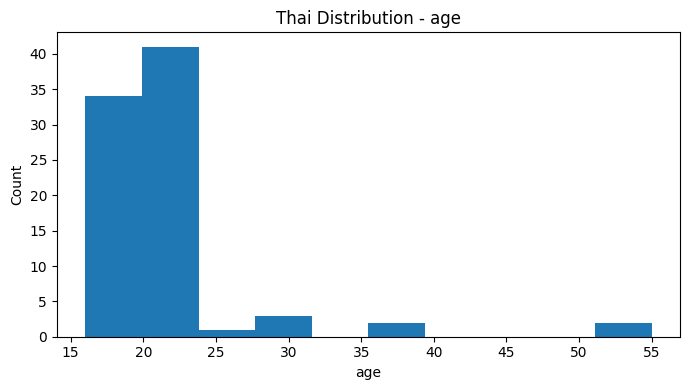

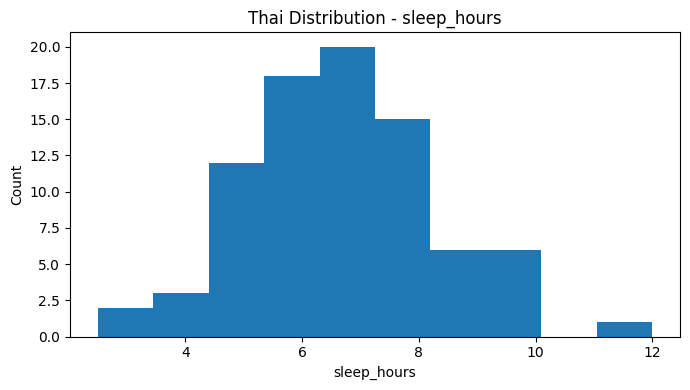

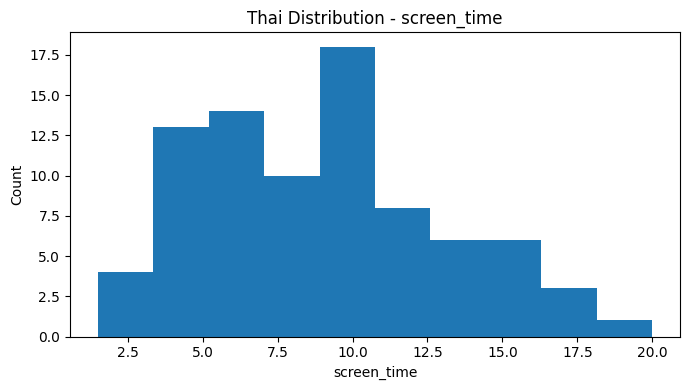

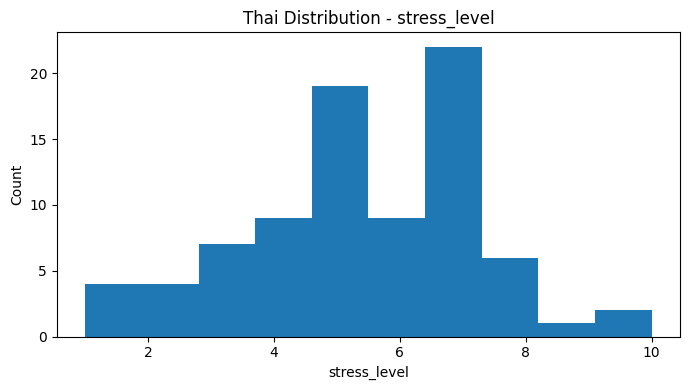

,morning_freshness,Count
0,ไม่สดชื่น,53
1,สดชื่น,30


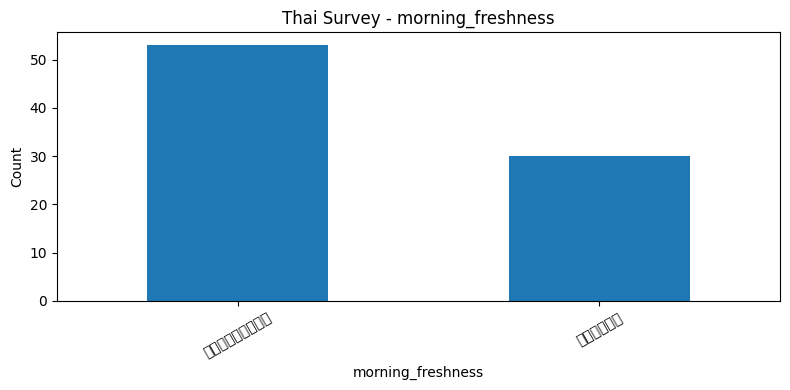

,use_phone_before_sleep,Count
0,ใช่,81
1,ไม่ใช่,2


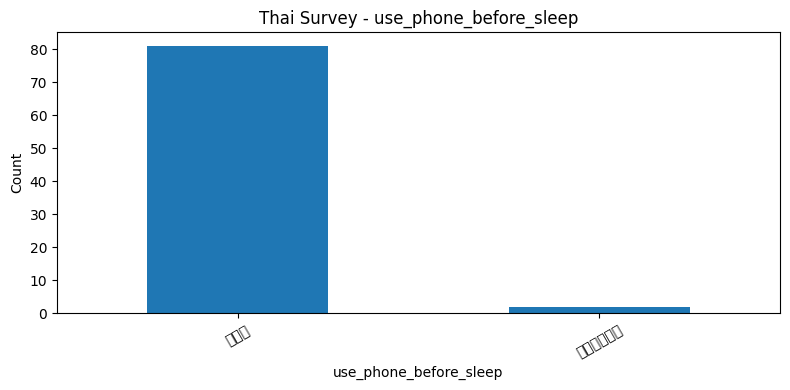

,phone_anxiety,Count
0,ไม่หงุดหงิด/ไม่วิตกกังวล,59
1,หงุดหงิด/วิตกกังวล,24


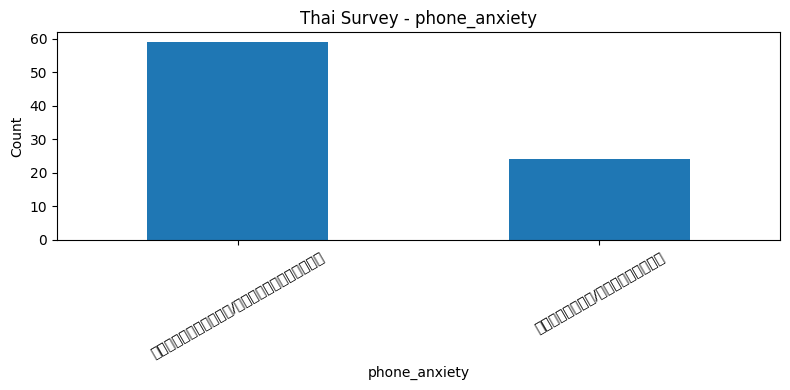

,health_app_use,Count
0,ไม่ใช่,56
1,ใช่,27


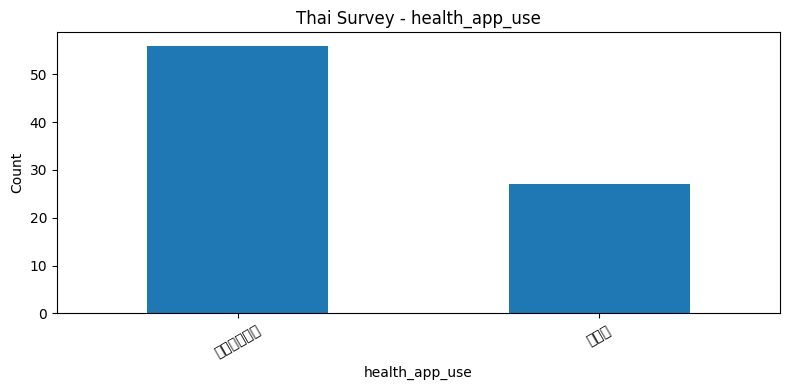

,sleep_quality,Count
0,ไม่ดี,42
1,ดี,41


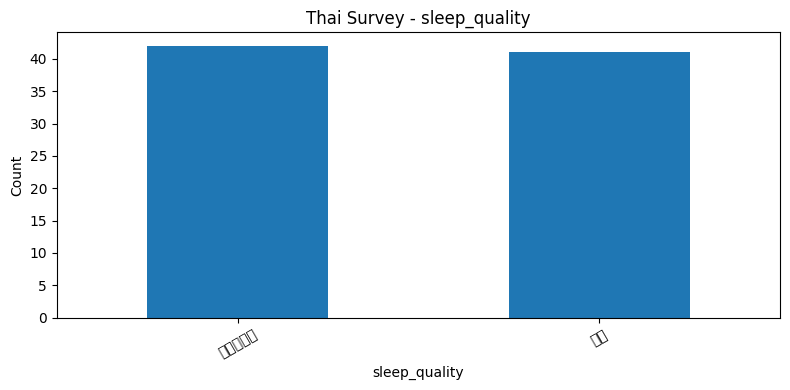

,phone_affects_sleep,Count
0,ใช่,45
1,ไม่แน่ใจ,28
2,ไม่ใช่,10


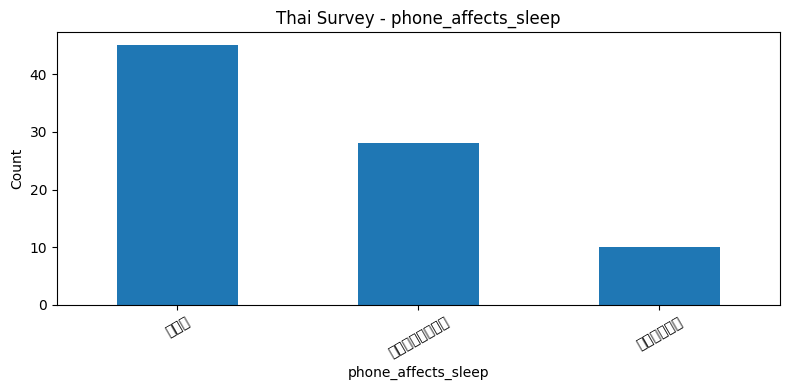

,age,sleep_hours,screen_time,stress_level
age,1.000000,-0.144883,-0.036105,-0.015420
sleep_hours,-0.144883,1.000000,-0.139560,-0.173140
screen_time,-0.036105,-0.139560,1.000000,-0.022014
stress_level,-0.015420,-0.173140,-0.022014,1.000000


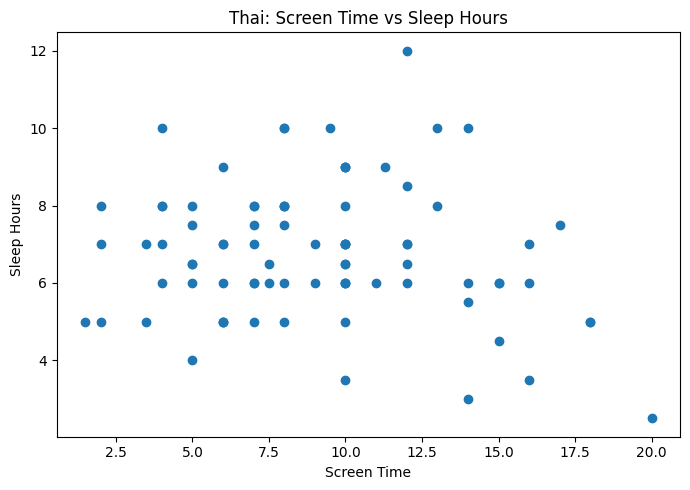


Thai Insight:
- Average age: 21.0
- Average sleep: 6.8 hours
- Average screen time: 9.1 hours
- Correlation screen vs sleep: -0.14

========== ENGLISH DATASET ==========


,Column,Data Type,Missing Values,Unique Values
0,age,int64,0,41
1,sleep_hours,int64,0,7
2,feel_rested,object,0,3
3,daily_screen_time,int64,0,11
4,use_before_sleep,object,0,2
5,stress_level,int64,0,10
6,anxiety/low_mood,object,0,2
7,wellness_apps,object,0,2
8,sleep_quality,object,0,2
9,screen_time_affects_sleep?,object,0,3


,age,sleep_hours,feel_rested,daily_screen_time,use_before_sleep,stress_level,anxiety/low_mood,wellness_apps,sleep_quality,screen_time_affects_sleep?
0,47,4,yes,11,yes,10,no,no,bad,yes
1,48,4,no,8,no,7,yes,yes,bad,yes
2,40,7,sometimes,10,no,4,no,yes,bad,yes
3,26,10,yes,5,yes,1,yes,no,good,no
4,47,5,yes,7,yes,7,yes,no,good,yes


,age,sleep_hours,daily_screen_time,stress_level
count,1095.000000,1095.000000,1095.000000,1095.000000
mean,34.812785,6.906849,6.398174,5.162557
std,11.967377,1.980826,2.647892,2.318171
min,15.000000,4.000000,2.000000,1.000000
25%,24.000000,5.000000,5.000000,3.000000
50%,35.000000,7.000000,6.000000,5.000000
75%,45.000000,9.000000,8.000000,7.000000
max,55.000000,10.000000,12.000000,10.000000


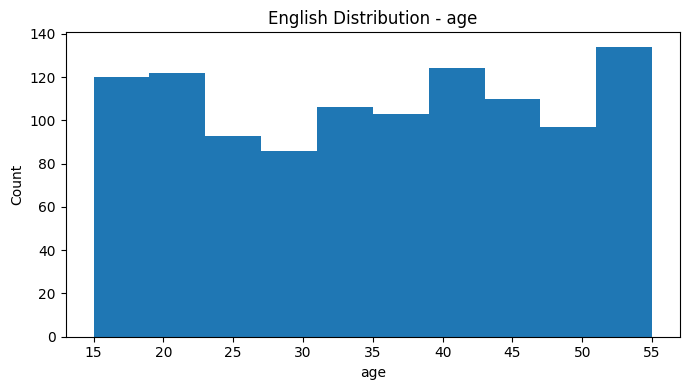

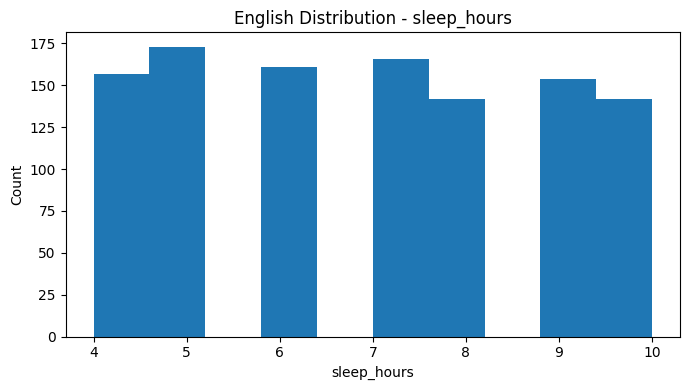

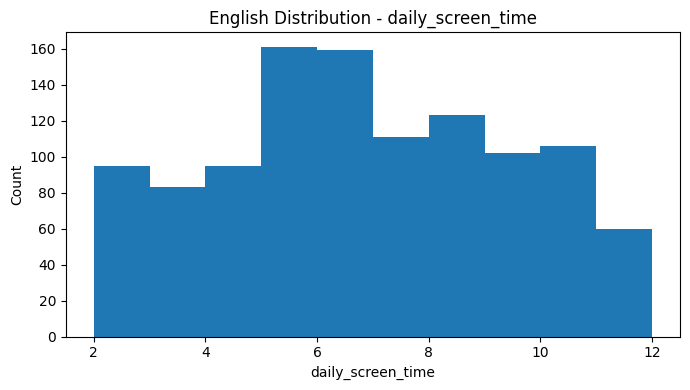

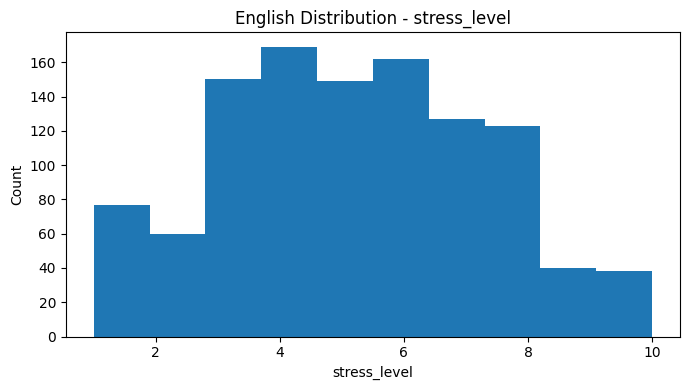

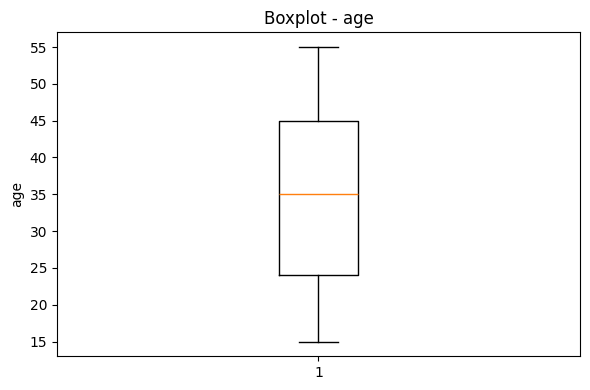

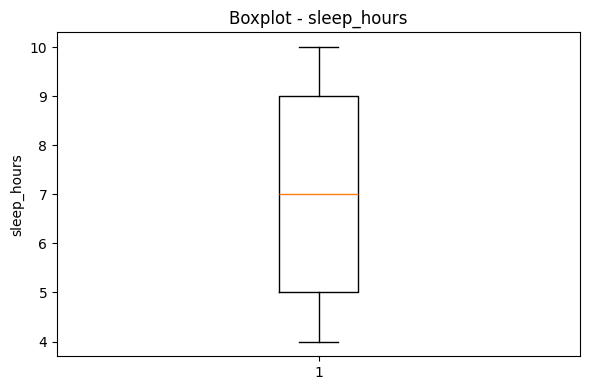

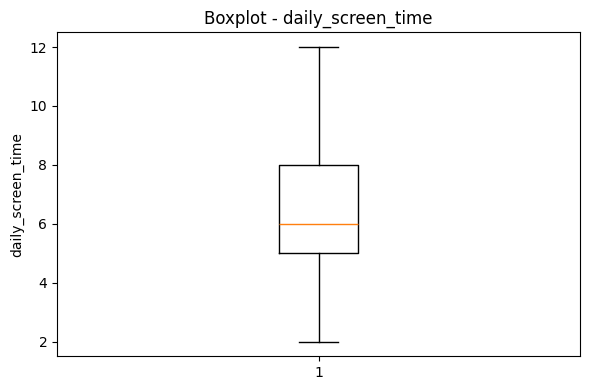

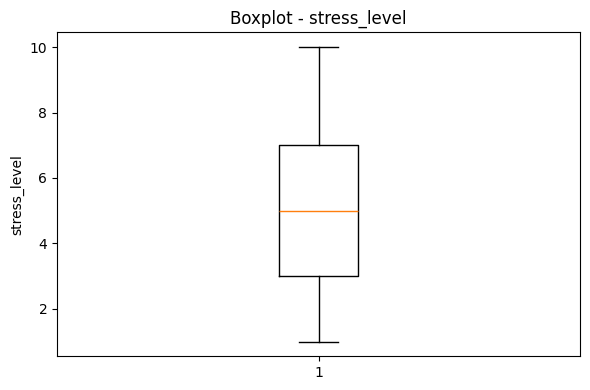

,feel_rested,Count
0,sometimes,382
1,no,376
2,yes,337


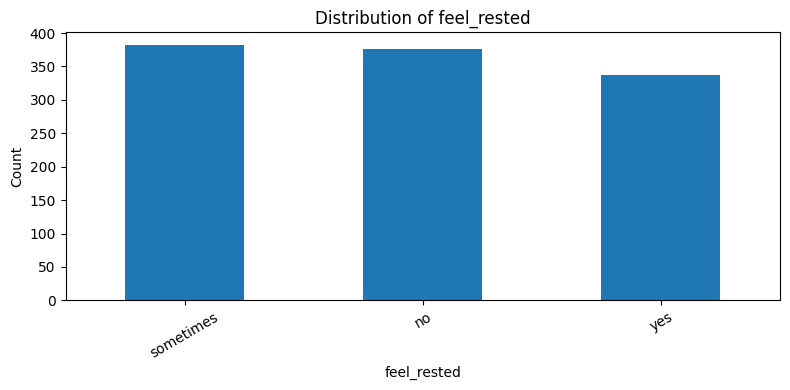

,use_before_sleep,Count
0,yes,582
1,no,513


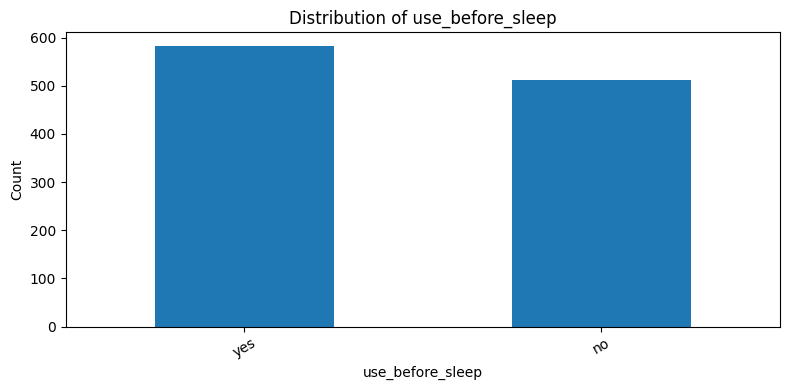

,anxiety/low_mood,Count
0,yes,568
1,no,527


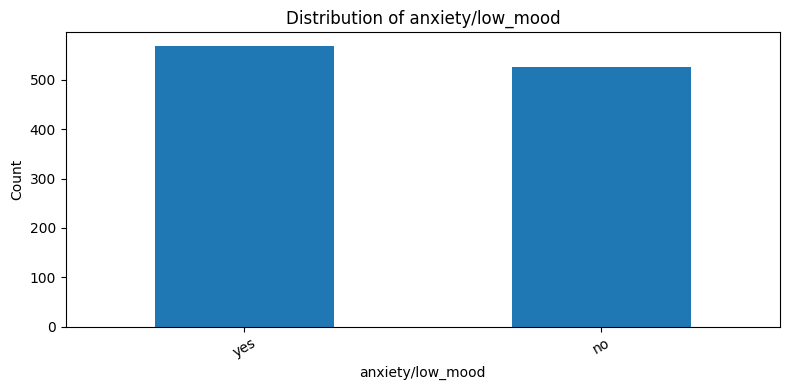

,wellness_apps,Count
0,no,561
1,yes,534


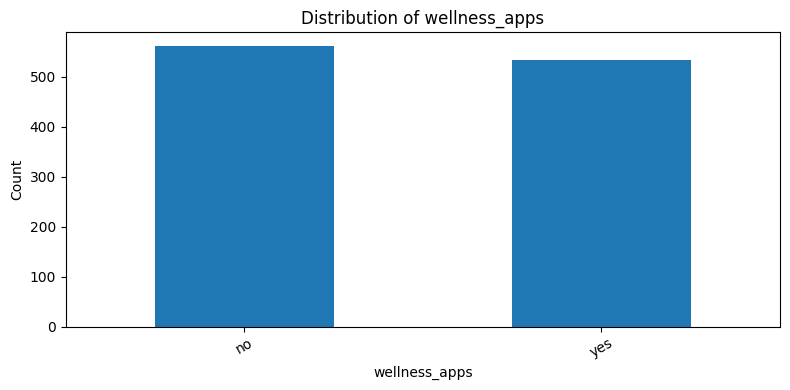

,sleep_quality,Count
0,good,691
1,bad,404


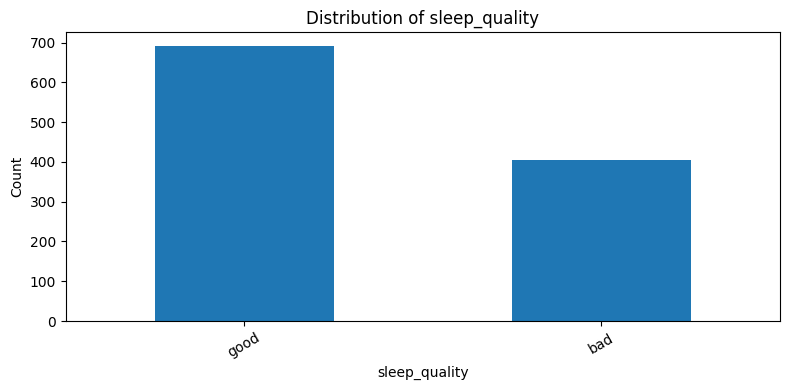

,screen_time_affects_sleep?,Count
0,no,605
1,yes,329
2,not sure,161


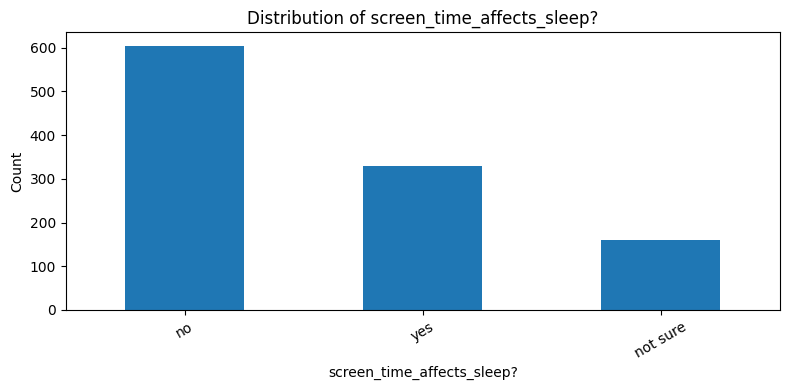

,age,sleep_hours,daily_screen_time,stress_level
age,1.000000,0.019469,0.007893,0.023800
sleep_hours,0.019469,1.000000,-0.730455,-0.647238
daily_screen_time,0.007893,-0.730455,1.000000,0.529856
stress_level,0.023800,-0.647238,0.529856,1.000000


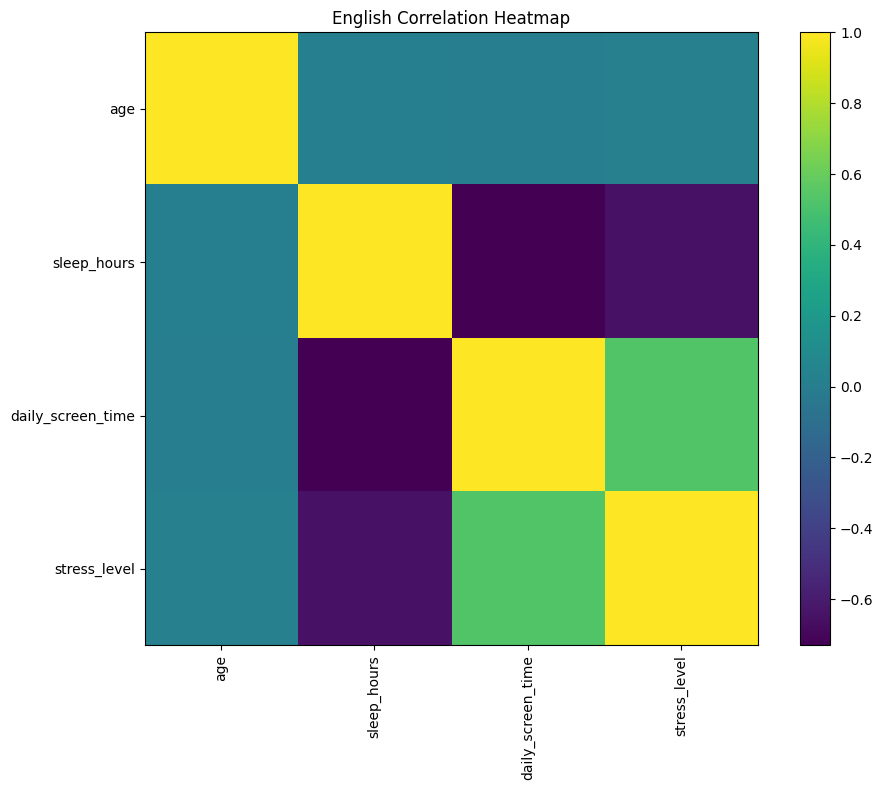

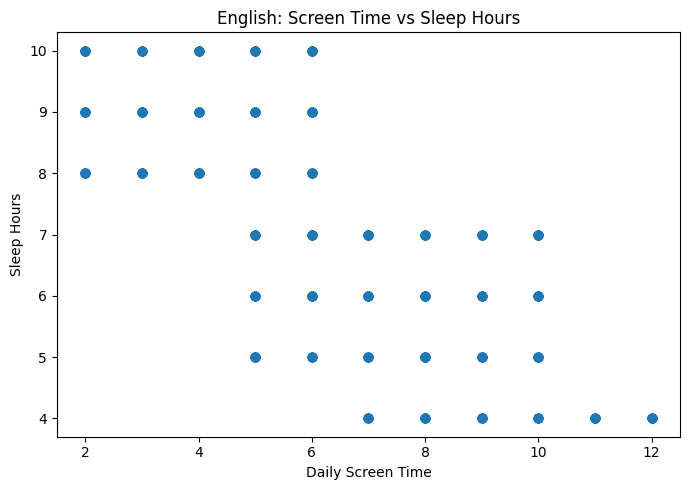


English Insight:
- Average age: 34.8
- Average sleep: 6.9 hours
- Average screen time: 6.4 hours
- Correlation screen vs sleep: -0.73


In [29]:
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display
import matplotlib as mpl
import warnings

# ======================================
# FIX FONT WARNING
# ======================================
warnings.filterwarnings("ignore")
mpl.rcParams.update(mpl.rcParamsDefault)
plt.rcParams['font.family'] = 'sans-serif'

# ======================================
# LOAD DATA
# ======================================
df_th = pd.read_excel("cleaned_thai_data.xlsx")
df_en = pd.read_csv("cleaned_english_data.csv")

# ======================================
# FUNCTION FOR SUMMARY TABLE
# ======================================
def dataset_summary(df):
    return pd.DataFrame({
        "Column": df.columns,
        "Data Type": df.dtypes.values,
        "Missing Values": df.isnull().sum().values,
        "Unique Values": df.nunique().values
    })

# ======================================
# THAI DATASET ANALYSIS
# ======================================
print("========== THAI SURVEY DATA ==========")

display(dataset_summary(df_th).style.set_caption("Thai Dataset Summary"))
display(df_th.head().style.set_caption("Thai Dataset Preview"))

thai_num = df_th.select_dtypes(include=['int64','float64'])

display(
    thai_num.describe().style
    .set_caption("Thai Numerical Summary")
)

# Histogram
for col in thai_num.columns:
    plt.figure(figsize=(7,4))
    plt.hist(df_th[col].dropna(), bins=10)
    plt.title(f"Thai Distribution - {col}")
    plt.xlabel(col)
    plt.ylabel("Count")
    plt.tight_layout()
    plt.show()

# Category analysis
for col in df_th.select_dtypes(include='object').columns:
    value_table = df_th[col].value_counts().reset_index()
    value_table.columns = [col, "Count"]

    display(
        value_table.style
        .set_caption(f"Thai Survey Response: {col}")
    )

    plt.figure(figsize=(8,4))
    df_th[col].value_counts().plot(kind='bar')
    plt.title(f"Thai Survey - {col}")
    plt.xlabel(col)
    plt.ylabel("Count")
    plt.xticks(rotation=30)
    plt.tight_layout()
    plt.show()

# Correlation
thai_corr = thai_num.corr()

display(
    thai_corr.style
    .background_gradient()
    .set_caption("Thai Correlation Matrix")
)

# Scatter
if "screen_time" in df_th.columns and "sleep_hours" in df_th.columns:
    plt.figure(figsize=(7,5))
    plt.scatter(df_th["screen_time"], df_th["sleep_hours"])
    plt.xlabel("Screen Time")
    plt.ylabel("Sleep Hours")
    plt.title("Thai: Screen Time vs Sleep Hours")
    plt.tight_layout()
    plt.show()

    corr_th = df_th["screen_time"].corr(df_th["sleep_hours"])

    print("\nThai Insight:")
    print(f"- Average age: {df_th['age'].mean():.1f}")
    print(f"- Average sleep: {df_th['sleep_hours'].mean():.1f} hours")
    print(f"- Average screen time: {df_th['screen_time'].mean():.1f} hours")
    print(f"- Correlation screen vs sleep: {corr_th:.2f}")

# ======================================
# ENGLISH DATASET ANALYSIS
# ======================================
print("\n========== ENGLISH DATASET ==========")

display(dataset_summary(df_en).style.set_caption("English Dataset Summary"))
display(df_en.head().style.set_caption("English Dataset Preview"))

en_num = df_en.select_dtypes(include=['int64','float64'])

display(
    en_num.describe().style
    .set_caption("English Statistical Summary")
)

# Histogram
for col in en_num.columns:
    plt.figure(figsize=(7,4))
    plt.hist(df_en[col].dropna(), bins=10)
    plt.title(f"English Distribution - {col}")
    plt.xlabel(col)
    plt.ylabel("Count")
    plt.tight_layout()
    plt.show()

# Boxplot
for col in en_num.columns:
    plt.figure(figsize=(6,4))
    plt.boxplot(df_en[col].dropna())
    plt.title(f"Boxplot - {col}")
    plt.ylabel(col)
    plt.tight_layout()
    plt.show()

# Category analysis
for col in df_en.select_dtypes(include='object').columns:
    value_table = df_en[col].value_counts().reset_index()
    value_table.columns = [col, "Count"]

    display(
        value_table.style
        .set_caption(f"English Dataset Distribution: {col}")
    )

    plt.figure(figsize=(8,4))
    df_en[col].value_counts().plot(kind='bar')
    plt.title(f"Distribution of {col}")
    plt.xlabel(col)
    plt.ylabel("Count")
    plt.xticks(rotation=30)
    plt.tight_layout()
    plt.show()

# Correlation
en_corr = en_num.corr()

display(
    en_corr.style
    .background_gradient()
    .set_caption("English Correlation Matrix")
)

# Heatmap
plt.figure(figsize=(10,8))
plt.imshow(en_corr)
plt.colorbar()
plt.xticks(range(len(en_corr.columns)), en_corr.columns, rotation=90)
plt.yticks(range(len(en_corr.columns)), en_corr.columns)
plt.title("English Correlation Heatmap")
plt.tight_layout()
plt.show()

# Scatter
if "daily_screen_time" in df_en.columns and "sleep_hours" in df_en.columns:
    plt.figure(figsize=(7,5))
    plt.scatter(df_en["daily_screen_time"], df_en["sleep_hours"])
    plt.xlabel("Daily Screen Time")
    plt.ylabel("Sleep Hours")
    plt.title("English: Screen Time vs Sleep Hours")
    plt.tight_layout()
    plt.show()

    corr_en = df_en["daily_screen_time"].corr(df_en["sleep_hours"])

    print("\nEnglish Insight:")
    print(f"- Average age: {df_en['age'].mean():.1f}")
    print(f"- Average sleep: {df_en['sleep_hours'].mean():.1f} hours")
    print(f"- Average screen time: {df_en['daily_screen_time'].mean():.1f} hours")
    print(f"- Correlation screen vs sleep: {corr_en:.2f}")